In [19]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [20]:
!ls ../artifacts/datasets/

dataset_level_01_daily_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_04_daily_dept.parquet
dataset_level_05_daily_state_cat.parquet
dataset_level_06_daily_store.parquet
dataset_level_07_daily_state_dept.parquet
dataset_level_08_daily_store_cat.parquet
dataset_level_09_daily_store_dept.parquet
dataset_level_10_weekly_item.parquet
dataset_level_11_weekly_item_state.parquet
dataset_level_12_weekly_item_store.parquet


In [21]:
results_df = pd.read_parquet('../output/experiment_results.parquet')
results_df.sort_values('wape').head(10)

,level_id,level_name,grain,target,target_type,split,horizon,n_series,n_rows,fit_time_s,wape,bias,wrmsse,model_path
26,1,total,daily,cum365,cumulative,valid,365,1,1576,0.03,0.024306,-0.024306,NaN,/home/njimenez/Workspace/magister/forecast-tfm...
24,1,total,daily,cum42,cumulative,valid,365,1,1899,0.12,0.026475,0.021023,NaN,/home/njimenez/Workspace/magister/forecast-tfm...
22,1,total,daily,cum35,cumulative,valid,365,1,1906,0.09,0.028751,0.024571,NaN,/home/njimenez/Workspace/magister/forecast-tfm...
20,1,total,daily,cum28,cumulative,valid,365,1,1913,0.06,0.030585,0.023946,NaN,/home/njimenez/Workspace/magister/forecast-tfm...
2,1,total,daily,sales,sales,valid,21,1,1941,0.12,0.033788,0.007337,0.303125,/home/njimenez/Workspace/magister/forecast-tfm...
18,1,total,daily,cum21,cumulative,valid,365,1,1920,0.11,0.033918,0.024390,NaN,/home/njimenez/Workspace/magister/forecast-tfm...
3,1,total,daily,sales,sales,valid,28,1,1941,0.12,0.036405,0.000617,0.304209,/home/njimenez/Workspace/magister/forecast-tfm...
74,3,cat,daily,cum21,cumulative,valid,365,3,5760,0.38,0.037120,-0.023040,NaN,/home/njimenez/Workspace/magister/forecast-tfm...
4,1,total,daily,sales,sales,valid,35,1,1941,0.12,0.037460,0.000387,0.305394,/home/njimenez/Workspace/magister/forecast-tfm...
16,1,total,daily,cum14,cumulative,valid,365,1,1927,0.11,0.037576,0.023338,NaN,/home/njimenez/Workspace/magister/forecast-tfm...


# Data

In [22]:
LEVEL = 'level_09_daily_store_dept'

In [23]:
df = pd.read_parquet(f'../artifacts/datasets/dataset_{LEVEL}.parquet')

df = df.sort_values("date").copy()
df["date"] = pd.to_datetime(df["date"])

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-29,297.0,2.293535,NaN,NaN,0.991603,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,1533.0,3305.0,5047.0,6652.0,8373.0,10069.0,75935.0,1.0,0,NaN,8.0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97050,HOUSEHOLD_1_HOUSEHOLD_CA_1_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,2011-01-29,361.0,3.903850,NaN,NaN,1.002209,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2143.0,4003.0,6065.0,8223.0,10286.0,12291.0,123596.0,1.0,0,NaN,8.0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27174,FOODS_2_FOODS_TX_1_TX,TOTAL,FOODS_2,FOODS,TX_1,TX,2011-01-29,390.0,3.059897,NaN,NaN,0.933859,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2659.0,5183.0,7548.0,9379.0,11639.0,14332.0,124580.0,1.0,0,NaN,8.0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98991,HOUSEHOLD_1_HOUSEHOLD_CA_2_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_2,CA,2011-01-29,529.0,3.998828,NaN,NaN,1.026361,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2388.0,4869.0,7210.0,9707.0,11927.0,14439.0,145585.0,1.0,0,NaN,8.0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25233,FOODS_2_FOODS_CA_4_CA,TOTAL,FOODS_2,FOODS,CA_4,CA,2011-01-29,351.0,2.981197,NaN,NaN,0.901778,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,1845.0,3654.0,5408.0,7130.0,9040.0,10951.0,95545.0,1.0,0,NaN,8.0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [24]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]

FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

In [25]:
VALID_MONTHS = 18
TEST_MONTHS = 6

first_date = df["date"].min()
last_date = df["date"].max()

test_start = last_date - pd.DateOffset(months=TEST_MONTHS)
valid_start = test_start - pd.DateOffset(months=VALID_MONTHS)

train = df[df["date"] < valid_start]
valid = df[(df["date"] >= valid_start) & (df["date"] < test_start)]
test = df[df["date"] >= test_start]

print(f"Dataset starts : {first_date:%Y-%m-%d} ({len(df):,} rows)")
print(f"Validation start : {valid_start:%Y-%m-%d} ({len(train):,} rows)")
print(f"Test start       : {test_start:%Y-%m-%d} ({len(valid):,} rows)")
print(f"Dataset ends   : {last_date:%Y-%m-%d} ({len(test):,} rows)")

X_train = train[FEATURES].copy()
y_train = train[TARGET]

X_valid = valid[FEATURES].copy()
y_valid = valid[TARGET]

X_test = test[FEATURES].copy()
y_test = test[TARGET]

for X in (X_train, X_valid, X_test):
    for col in CATEGORICAL_FEATURES:
        X[col] = X[col].astype("category")

Dataset starts : 2011-01-29 (135,870 rows)
Validation start : 2014-05-22 (84,630 rows)
Test start       : 2015-11-22 (38,430 rows)
Dataset ends   : 2016-05-22 (12,810 rows)


# Modelo simple

In [26]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from src.evaluation.metrics import compute_wrmsse, wape

def wape_metric(y_true, y_pred):
    score = wape(y_true, y_pred)
    return "wape", score, False  # menor es mejor

def wrmsse_metric(y_true, y_pred):
    score = compute_wrmsse(train, valid, y_pred)
    return "wrmsse", score, False

In [27]:
model = LGBMRegressor(
    objective="l1",
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(25, first_metric_only=True),
        lgb.log_evaluation(5),
    ],
)

Training until validation scores don't improve for 25 rounds
[5]	valid_0's l1: 258.172	valid_0's wrmsse: 2.44015
[10]	valid_0's l1: 171.519	valid_0's wrmsse: 1.6982
[15]	valid_0's l1: 119.913	valid_0's wrmsse: 1.29052
[20]	valid_0's l1: 90.7753	valid_0's wrmsse: 1.0409
[25]	valid_0's l1: 73.852	valid_0's wrmsse: 0.883549
[30]	valid_0's l1: 64.6012	valid_0's wrmsse: 0.790463
[35]	valid_0's l1: 59.3925	valid_0's wrmsse: 0.733691
[40]	valid_0's l1: 56.8681	valid_0's wrmsse: 0.702995
[45]	valid_0's l1: 55.5403	valid_0's wrmsse: 0.685481
[50]	valid_0's l1: 54.8551	valid_0's wrmsse: 0.675894
[55]	valid_0's l1: 54.2417	valid_0's wrmsse: 0.668109
[60]	valid_0's l1: 53.6188	valid_0's wrmsse: 0.66013
[65]	valid_0's l1: 53.1697	valid_0's wrmsse: 0.654285
[70]	valid_0's l1: 52.7141	valid_0's wrmsse: 0.64833
[75]	valid_0's l1: 52.2839	valid_0's wrmsse: 0.643054
[80]	valid_0's l1: 51.9735	valid_0's wrmsse: 0.639521
[85]	valid_0's l1: 51.6946	valid_0's wrmsse: 0.636091
[90]	valid_0's l1: 51.418	valid

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
y_pred = model.predict(X_test)

wape_test = wape(y_test, y_pred)
wrmsse_test = compute_wrmsse(train, test, y_pred)

print(f"Test WAPE: {wape_test:.2%}")
print(f"Test WRMSSE: {wrmsse_test:.4f}")

Test WAPE: 15.31%
Test WRMSSE: 1.1969


# Modelo optimizado

In [29]:
import optuna
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb
import numpy as np

In [30]:
import lightgbm as lgb
import numpy as np
import optuna
from optuna.integration import LightGBMPruningCallback


cat_cols = CATEGORICAL_FEATURES.copy()

In [31]:
def objective(trial):

    model = lgb.LGBMRegressor(
        objective="tweedie",
        tweedie_variance_power=trial.suggest_float("tweedie_variance_power", 1.1, 1.4),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        n_estimators=3000,
        num_leaves=trial.suggest_int("num_leaves", 31, 512),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 300),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=wrmsse_metric,
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(50, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, "wrmsse"),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    
    return final_wrmsse

In [32]:
import os

os.makedirs("../artifacts", exist_ok=True)

study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
        multivariate=True,
        group=True,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(
    objective,
    n_trials=200,
    timeout=300,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

/tmp/ipykernel_97516/1808609616.py:10: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_97516/1808609616.py:10: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-08-04 21:11:43,529] Using an existing study with name 'study_level_09_daily_store_dept' instead of creating a new one.


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-04 21:12:05,729] Trial 4 finished with value: 0.5718569872436081 and parameters: {'tweedie_variance_power': 1.2123620356542089, 'learning_rate': 0.08927180304353628, 'num_leaves': 383, 'max_depth': 11, 'min_child_samples': 63, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}. Best is trial 2 with value: 0.5545067138241218.
[I 2026-08-04 21:12:08,403] Trial 5 pruned. Trial was pruned at iteration 10.
[I 2026-08-04 21:12:09,657] Trial 6 pruned. Trial was pruned at iteration 10.
[I 2026-08-04 21:12:40,911] Trial 7 finished with value: 0.5577335647257419 and parameters: {'tweedie_variance_power': 1.2542703315240835, 'learning_rate': 0.03912141628549695, 'num_leaves': 53, 'max_depth': 11, 'min_child_samples': 67, 'subsample': 0.5325257964926398, 'colsample_bytree': 0.9744427686266666, 'reg_alpha': 6.732248920775331, 'reg_lambda': 1.1015056790269626}. Best is trial 2 with value: 0.554506713

# Modelo final

In [33]:
model_params = {
    k: v for k, v in best_trial.params.items()
    if not k.startswith("use_")
}

# with open("best_params.json", "w") as f:
#     json.dump(model_params, f, indent=2)

final_model = lgb.LGBMRegressor(
    objective="l1",
    n_estimators=5000,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=cat_cols,
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),
        lgb.log_evaluation(0),
    ],
)

final_model.booster_.save_model("final_model.txt")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1395]	valid_0's l1: 48.2545	valid_0's wrmsse: 0.597023
Evaluated only: l1


In [34]:
y_pred = final_model.predict(X_test, num_iteration=final_model.best_iteration_)

wape_test = wape(y_test, y_pred)
wrmsse_test = compute_wrmsse(train, test, y_pred)

print(f"Test WAPE: {wape_test:.2%}")
print(f"Test WRMSSE: {wrmsse_test:.4f}")

Test WAPE: 14.79%
Test WRMSSE: 1.1433


# Explora predicciones

In [35]:
df_pred = pd.DataFrame({
    "agg_id": test["agg_id"],
    "date": test["date"],
    "y_true": y_test.astype(int),
    "y_pred": y_pred.round().astype(int),
})

df_pred['error'] = df_pred['y_true'] - df_pred['y_pred']

<Axes: xlabel='date'>

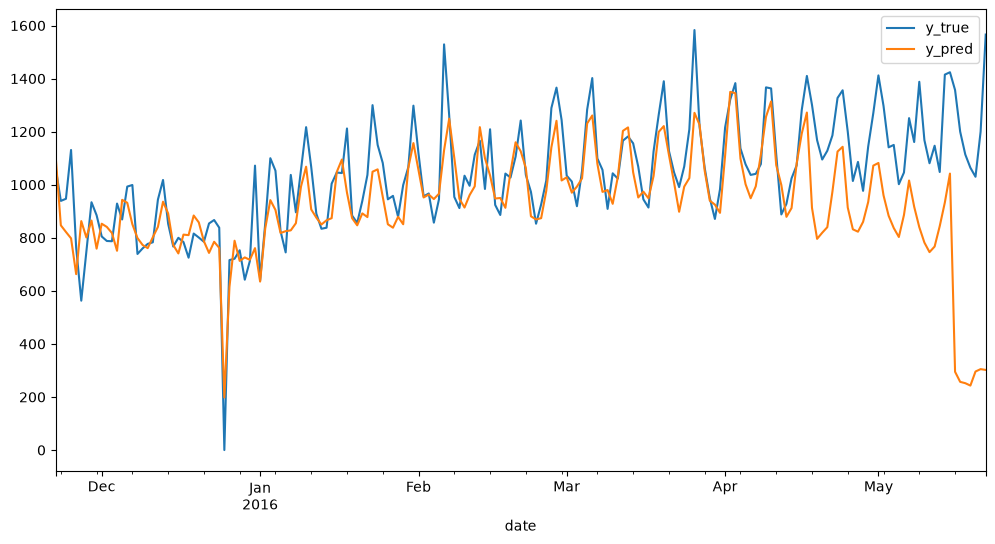

In [36]:
df_pred.query('agg_id == "FOODS_3_FOODS_CA_4_CA"').plot(x="date", y=["y_true", "y_pred"], figsize=(12, 6))